# P4 — Nowcaster

L2 calibration and prediction diagnostics for the regime nowcaster. This notebook
answers one question — *how good are the nowcaster's probabilities, honestly measured?*
— and it answers it in two deliberately separate halves that must never be read as
the same numbers:

1. **A cheap, in-process, non-walk-forward diagnostic fit** whose only job is to make
   design §5.1's **persistence trap** visible. A classifier that just repeats last
   month's state scores high *overall* accuracy while being wrong at exactly the
   transitions guidance depends on, so overall, transition-window and steady-state
   accuracy are always shown together — never `overall_accuracy` alone.
2. **The real walk-forward's already-persisted forecast quality** — Brier,
   calibration and confusion — loaded from `outputs/reports/platform/`, checked
   against a stated plausibility band before anything derived from it is drawn.

Nothing here sweeps a nowcaster hyperparameter (`embargo_months`, `label_horizon`,
`n_splits`) or a labeler hyperparameter (`K`, `lambda`, `n_restarts`): the fit uses
the shipped config defaults, for display only (D-14's no-sweep discipline extended
to L2). Nothing here re-runs the walk-forward, writes a checkpoint, or logs a trial.

**Prerequisites**

- `python scripts/build_platform_data.py` — builds the `monthly_features` checkpoint
  (and the full-span frame the drift panel reads).
- `python -m trading_crab_lib.platform.evaluation.report` — writes the three
  persisted model-metrics artifacts this notebook renders
  (`model_metrics_brier.parquet`, `model_metrics_calibration.parquet`,
  `model_metrics_confusion.parquet`).

In [1]:
%matplotlib inline
import logging

logging.basicConfig(level=logging.INFO)

from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.plotting import drift as pdrift
from trading_crab_lib.platform.plotting import nowcaster as pnowcaster
from trading_crab_lib.platform import taxonomy
from trading_crab_lib.platform.honesty.holdout import DEFAULT_HOLDOUT_CUTOFF

cfg = load_platform_config()
# Never display cfg directly (T-06-01) -- it carries a live FRED_API_KEY.
# redacted_config() replaces every *api_key value before anything is shown.
print("platform config sections:", sorted(pplot.redacted_config(cfg).keys()))
print("holdout cutoff:", DEFAULT_HOLDOUT_CUTOFF)

platform config sections: ['allocation', 'backtest', 'cv', 'data', 'fred_daily', 'fred_monthly', 'fred_vintage', 'holdout', 'labeling', 'macrotrends_monthly', 'multpl_monthly', 'paid_providers', 'registry', 'report', 'splice', 'taxonomy', 'tiingo', 'tripwire', 'universe']
holdout cutoff: 2020-12-31


## The nowcaster's inputs — features, and the labels it is trained against

The nowcaster's target is the L1 labeler's state path. This cell reuses **P3's exact
labeling entrypoint**, `pplot.compute_regime_labeling`, rather than fitting a second
labeler here: two notebooks disagreeing about what "the regimes" are would make every
downstream number in both of them unreadable.

`compute_regime_labeling` routes every write to the notebook scratch namespace
(`data/checkpoints/platform_notebook/`), never the production platform checkpoint
namespace (D-10). Opening this notebook cannot overwrite a pipeline artifact.

In [2]:
monthly_features = pplot.load_platform_checkpoint(
    "monthly_features", rebuild_hint="python scripts/build_platform_data.py"
)
print(
    "monthly_features:",
    monthly_features.shape,
    monthly_features.index.min().date(),
    "->",
    monthly_features.index.max().date(),
)

labeling_result = pplot.compute_regime_labeling(monthly_features, cfg)
labels = labeling_result["regime_labels"]["state"]
print(
    "labels:",
    len(labels),
    "months",
    labels.index.min().date(),
    "->",
    labels.index.max().date(),
    "| states:",
    sorted(labels.unique().tolist()),
)

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (708 rows × 53 cols)


monthly_features: (708, 53) 1962-01-31 -> 2020-12-31


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint saved: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint saved: regime_confidences  (372 rows × 5 cols)


...

INFO:trading_crab_lib.platform.labeling.diagnostics:Labeling Diagnostics (design §4.4, report-only D-02)
  state 0: occupancy=2.4%  median_sojourn=9.0mo  state 0: high credit_spread_baa_aaa, high fred_vix, high realized_vol_3m
  state 1: occupancy=15.6%  median_sojourn=58.0mo  state 1: high cape_shiller, low div_yield, low gold
  state 2: occupancy=32.3%  median_sojourn=60.0mo  state 2: low oil, low gold, high real_rate_level
  state 3: occupancy=32.0%  median_sojourn=59.5mo  state 3: low real_rate_level, low curve_10y3m, high gold
  state 4: occupancy=17.7%  median_sojourn=66.0mo  state 4: high oil, high gold, high curve_10y2y
  artifact: /home/user/claude-scratch-work/data/checkpoints/platform_notebook/labeling_diagnostics.parquet


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_confidences  (372 rows × 5 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_profiles  (5 rows × 2 cols)


Labeling Diagnostics (design §4.4, report-only D-02)
  state 0: occupancy=2.4%  median_sojourn=9.0mo  state 0: high credit_spread_baa_aaa, high fred_vix, high realized_vol_3m
  state 1: occupancy=15.6%  median_sojourn=58.0mo  state 1: high cape_shiller, low div_yield, low gold
  state 2: occupancy=32.3%  median_sojourn=60.0mo  state 2: low oil, low gold, high real_rate_level
  state 3: occupancy=32.0%  median_sojourn=59.5mo  state 3: low real_rate_level, low curve_10y3m, high gold
  state 4: occupancy=17.7%  median_sojourn=66.0mo  state 4: high oil, high gold, high curve_10y2y
  artifact: /home/user/claude-scratch-work/data/checkpoints/platform_notebook/labeling_diagnostics.parquet
labels: 372 months 1990-01-31 -> 2020-12-31 | states: [0, 1, 2, 3, 4]


## The persistence trap (design §5.1)

A trivial classifier that predicts "same state as last month" scores near-90% overall
on a series whose median sojourn is ~5 years. That number is worthless: the whole
point of a nowcaster is to be right *at* the regime break, and a persistence
classifier is wrong at every single one. So this panel never shows overall accuracy
alone — it shows all three figures together:

| figure | what it measures |
|---|---|
| `overall_accuracy` | every scored month |
| `transition_accuracy` | months within ±3 of a label change — **the ones that matter** |
| `steady_state_accuracy` | every other month |

A large gap between the second and third is the persistence trap showing itself.

**This is an in-process, non-walk-forward diagnostic fit.** It is *not* the real
walk-forward's per-step forecasts (those come from the persisted artifacts in the
next section, and they are different numbers computed a different way). It writes no
checkpoint and logs no trial — a notebook glance is not an evaluated configuration,
and recording it as one would corrupt the multiple-testing ledger the deflated
Sharpe denominator is computed from at design freeze.

Feature columns are narrowed to the 13-column lean taxonomy set, the same set
`backtest/driver.py` refits L1/L2 on.

In [3]:
result = pnowcaster.fit_nowcaster_diagnostics(monthly_features, labels, cfg)

print("scored rows:", result["X"].shape[0], "over", result["X"].shape[1], "lean features")
print("scored span:", result["X"].index.min().date(), "->", result["X"].index.max().date())
print("classes:", result["classes"])
print()
for key, value in result["metrics"].items():
    print(f"  {key:24s} {value:.4f}")

INFO:trading_crab_lib.platform.plotting.nowcaster:fit_nowcaster_diagnostics: 360 scored rows over 13 lean features; overall=0.7139 transition=0.5250 steady=0.7375 (diagnostic only — no trial logged, no checkpoint written)


scored rows: 360 over 13 lean features
scored span: 1990-01-31 -> 2019-12-31
classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

  overall_accuracy         0.7139
  transition_accuracy      0.5250
  steady_state_accuracy    0.7375


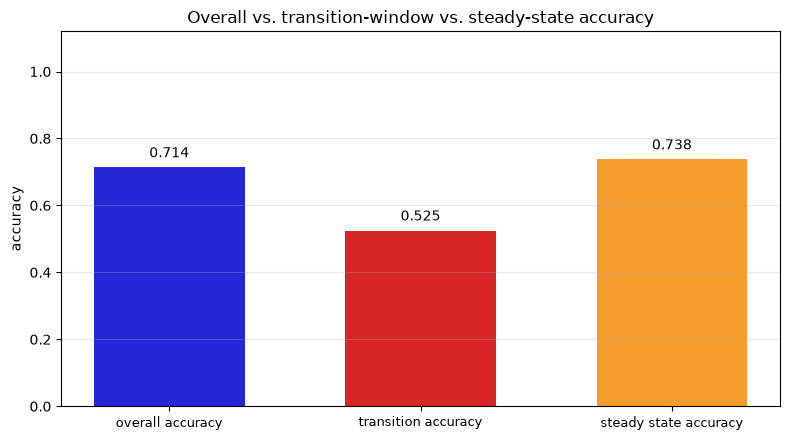

In [4]:
pnowcaster.plot_transition_window_accuracy(result["metrics"]);

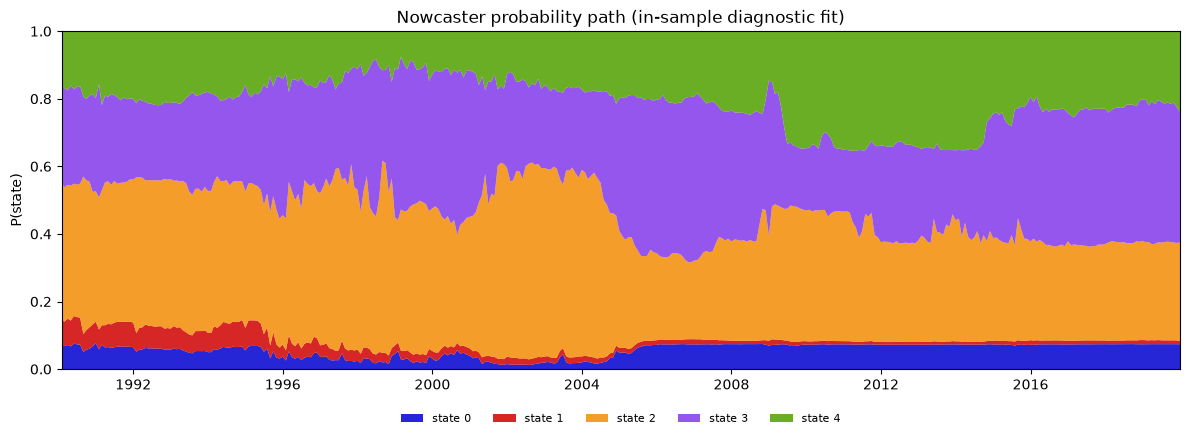

In [5]:
pnowcaster.plot_proba_over_time(result["X"].index, result["proba"], result["classes"]);

## The real walk-forward's persisted forecast quality — and an amber finding

Everything below is **loaded, never recomputed**. `run_backtest()` and
`run_full_backtest_evaluation()` are not called anywhere in this notebook; these are
the artifacts the honest walk-forward already wrote.

The Brier value is checked against its plausibility band **before** anything derived
from it is drawn (06-VALIDATION.md). Two facts about that band matter:

- This codebase's `compute_brier_multiclass` computes `mean((p - onehot)²)` over the
  whole `(n, K)` array, so its range is **[0, 1] — not the textbook [0, 2]**. A band
  written against [0, 2] would be silently wrong.
- The K=5 no-skill reference is `(K−1)/K² = 0.16`. `pdrift.assert_brier_plausible`
  is the single source of that floor; it is not re-derived here.

In [6]:
_REBUILD = "python -m trading_crab_lib.platform.evaluation.report"

brier_df = pplot.load_report_artifact("model_metrics_brier.parquet", rebuild_hint=_REBUILD)
calib_df = pplot.load_report_artifact("model_metrics_calibration.parquet", rebuild_hint=_REBUILD)
conf_df = pplot.load_report_artifact("model_metrics_confusion.parquet", rebuild_hint=_REBUILD)
print("brier:", brier_df.shape, "| calibration:", calib_df.shape, "| confusion:", conf_df.shape)

# Band check BEFORE any Brier-derived rendering.
verdict = pdrift.assert_brier_plausible(float(brier_df["brier"].iloc[0]), n_classes=5)
print()
print("verdict:", verdict)
print(
    f"\nobserved Brier {verdict['value']:.6f} vs K=5 no-skill floor {verdict['no_skill']:.4f} "
    f"-> beats_no_skill = {verdict['beats_no_skill']}"
)

brier: (1, 1) | calibration: (21, 7) | confusion: (20, 3)

verdict: {'value': 0.2087462934432449, 'no_skill': 0.16, 'beats_no_skill': False}

observed Brier 0.208746 vs K=5 no-skill floor 0.1600 -> beats_no_skill = False


### Reading that verdict plainly

**The observed multiclass Brier score is above the no-skill floor**
(0.2087 vs 0.16). On this metric the nowcaster **cannot presently claim to beat
random guessing**. That is an amber finding, not a green one, and it is stated here
rather than buried inside a "model trained" line.

This independently corroborates **audit item A8**: the presence of
`CalibratedClassifierCV` in the pipeline had been standing in for evidence that the
model *is* calibrated, and no pass band was ever asserted against its output. Asserting
one is what surfaced this.

**Phase 6 does not fix it.** No tuning, no recalibration, no threshold search, no
reweighting, no swapping the calibrator — this phase is the viewing surface, and its
scope fence is explicit (D-14). A notebook that quietly made this number look better
would be the exact failure the whole phase exists to prevent. The repair belongs to
whoever owns L2, with the finding recorded first.

The two panels below show *where* the miscalibration lives: reliability per state, and
the argmax confusion structure.

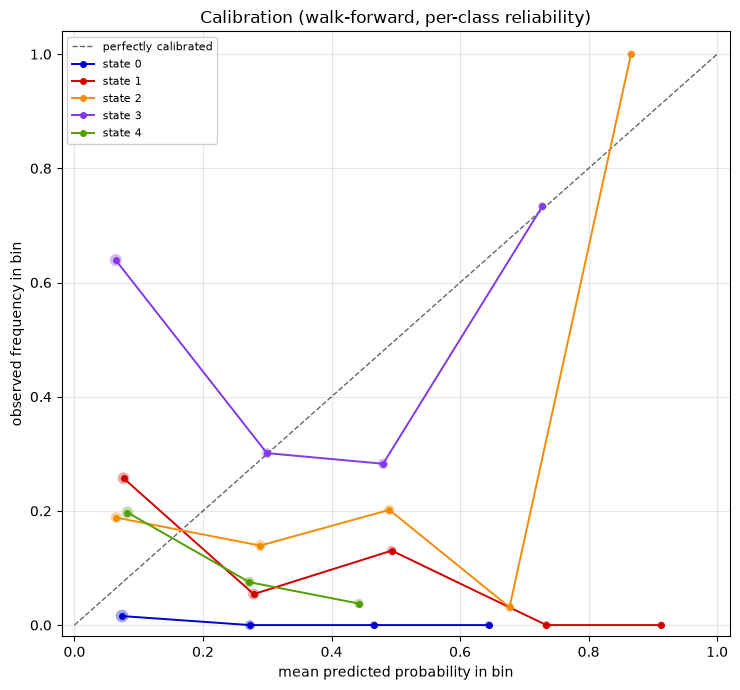

In [7]:
pnowcaster.plot_calibration_curve(calib_df);

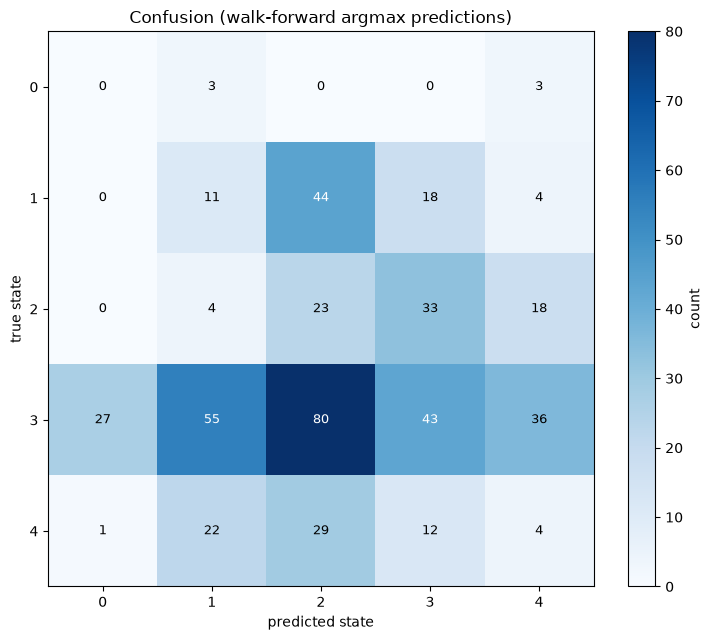

In [8]:
pnowcaster.plot_confusion_matrix(conf_df);

## Relationship to audit item A13

The three artifacts above summarize the walk-forward's **per-step filtered probability
path**. That is the *same* series which

- P3 draws side by side against the fixed-feature **smoothed reference** labeling, and
- P6 uses for the §5.4 sojourn / detection-lag headline.

A13 found that comparison is not interpretable, because the filtered path's active
feature set changes across the backtest while the reference's does not. The caveat
string below is `core.A13_CAVEAT`, rendered verbatim — the single source P3, P4 and P6
all use, so the wording cannot drift between notebooks.

**P4 neither attempts nor resolves the A13 comparison.** It characterizes this
module's *own* forecast quality — how well the filtered probabilities are calibrated
against the outcomes the evaluation scored them on — which is a separate question from
whether the reference and filtered paths are comparable to each other at all. Nothing
on this page should be read as evidence that A13 is settled.

In [9]:
print(pplot.A13_CAVEAT)

NOT INTERPRETABLE (audit item A13): this ratio compares a fixed-feature 'smoothed reference' labeling against the walk-forward's own per-window 'filtered' labeling, whose active feature set changes 7 times across the backtest (4 -> 6 -> 8 -> 9 -> 10 -> 12 -> 13 features). Their disagreement is therefore not purely detection delay, and no plausibility band around this number resolves that until A13 is settled.


## Full-span lean-feature drift (D-06 / D-07)

The fence in this project is on **fitting**, not on **looking**. Everything above is
computed on the dev-bounded frame; this panel alone reads the full span through
today, purely to look. No model here is fitted, tuned, or selected against post-2021
data.

Why a nowcaster notebook carries a drift panel: a feature can quietly stop being
predictive without ever becoming *invalid*. Its range stays plausible, no guard fires,
and the nowcaster keeps consuming it while it carries less and less signal — the
seasonality-style failure D-09 exists to catch. A large standardized mean shift
relative to the pre-2021 fitted window is the visible symptom.

Drift is measured against the **pre-2021 baseline**, and it is scale-invariant, so it
cannot catch a uniform units error — that is the plausibility guards' job (they run
in P2), not this table's. Per D-07, an observation here that would **change a
decision** belongs in `.planning/POST-2020-OBSERVATIONS.md` with its date; recording
something as decision-changing is an operator judgement, not an automatic consequence
of a flagged row.

In [10]:
full_features = pplot.load_full_span_checkpoint(
    "monthly_features", rebuild_hint="python scripts/build_platform_data.py"
)
print(
    "full span:",
    full_features.shape,
    full_features.index.min().date(),
    "->",
    full_features.index.max().date(),
)

lean_cols = sorted(taxonomy.lean_feature_set(cfg) & set(full_features.columns))
drift_df = pdrift.drift_report(full_features, lean_cols, cutoff=DEFAULT_HOLDOUT_CUTOFF)
print(f"\n{len(lean_cols)} lean features; {int(drift_df['flag'].sum())} flagged\n")
print(drift_df.to_string(index=False))

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (708 rows × 53 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (68 rows × 53 cols)


INFO:trading_crab_lib.platform.honesty.holdout:load_full_span: monthly_features -> 708 dev rows (<=2020-12-31) + 68 holdout rows (>2020-12-31) = 776


full span: (776, 53) 1962-01-31 -> 2026-08-31

13 lean features; 6 flagged

               column  n_baseline  n_current  baseline_mean  baseline_std  current_mean  standardized_mean_shift  ks_statistic    ks_pvalue  pct_beyond_2sigma  flag
                 gold         431         68     722.873527    481.821386   2552.255294                 3.796805      0.948956 1.079625e-64           0.970588  True
         cape_shiller         708         68      20.609675      8.078788     34.496324                 1.718902      0.832752 9.611474e-47           0.367647  True
            div_yield         708         66       0.029025      0.011418      0.014044                -1.312062      0.864792 1.332696e-50           0.000000  True
      real_rate_level         695         68       2.270129      2.352638     -0.807856                -1.308312      0.525984 2.119878e-16           0.323529  True
                  oil         431         68      43.801508     28.753075     77.074853            

## What an operator is checking on this page

1. **The persistence-trap split** — is `transition_accuracy` far below
   `steady_state_accuracy`? A large gap means the nowcaster is mostly reporting
   persistence and is weakest exactly where guidance depends on it.
2. **The Brier verdict** — `beats_no_skill` is currently `False`. Until that flips,
   no claim that the nowcaster beats random guessing is supportable from this metric.
3. **Calibration and confusion shape** — which states are over-confident, and which
   pairs the argmax actually confuses.
4. **Lean-feature drift** — which of the 13 features the nowcaster consumes have moved
   materially away from the window they were fitted on.

**P4 carries no sign-off cell and no per-run gate.** The single cold-start sign-off in
the whole notebook suite lives in P3 and stays there (D-15); adding a second place to
record a verdict would make it ambiguous which one is the record.